# QMJ Factor Research Tearsheet
### factor-lab — Quality-Minus-Junk Portfolio

**Objetivo de este documento:** presentar los resultados del rebalanceo más reciente del
factor Quality-Minus-Junk (QMJ), generado por el pipeline `run_pipeline.py`, para su
revisión por un comité de inversión o evaluador técnico. Cubre concentración de la cartera,
neutralidad sectorial y el rol de la neutralización de beta en la construcción de la señal.

**Hipótesis económica (Asness, Frazzini y Pedersen — "Quality Minus Junk"):** las empresas
de alta calidad — rentables, en crecimiento, financieramente seguras (bajo apalancamiento,
baja volatilidad de resultados) — no están consistentemente sobrevaloradas por el mercado
en proporción a esa calidad. Comprar el quintil de mayor calidad y vender el de menor calidad
("junk") produce, según los autores, retornos ajustados por riesgo positivos y persistentes
a través de mercados y periodos, parcialmente explicados por restricciones de arbitraje y
sesgos conductuales de los inversores hacia empresas especulativas de baja calidad.

Este notebook consume directamente `reports/optimal_weights.csv` — no recalcula el factor
ni la optimización, solo visualiza y audita el resultado del pipeline.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

weights = pd.read_csv("../reports/optimal_weights.csv")
print(f"{len(weights)} activos en el universo optimizado | "
      f"{(weights['weight'].abs() > 1e-6).sum()} con posición activa")
weights.head()

40 activos en el universo optimizado | 14 con posición activa


,ticker,cik,weight,gics_sector
0,T00,3000,0.08,Information Technology
1,T07,3007,0.08,Utilities
2,T10,3010,0.08,Health Care
3,T11,3011,0.08,Industrials
4,T30,3030,0.08,Consumer Staples


## Concentración de la cartera

El optimizador (`portfolio_optimizer.py`) restringe cada posición individual al rango
`[-max_weight, +max_weight]` (control de concentración) y la suma de valores absolutos de
los pesos a `max_leverage` (control de apalancamiento). Esto evita que el factor QMJ —
una señal cross-sectional pensada para diversificarse sobre decenas o cientos de nombres —
termine expresándose como una apuesta concentrada en un puñado de acciones por errores de
estimación en la covarianza o en el score. El gráfico siguiente muestra qué tan cerca del
tope de concentración están las posiciones más grandes en ambos extremos (largo y corto).

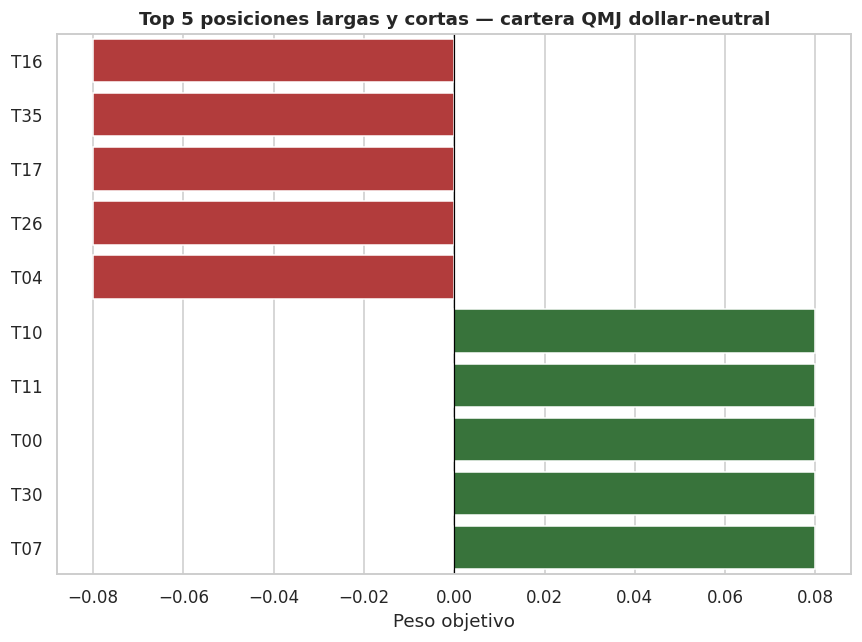

In [2]:
top_long = weights.sort_values("weight", ascending=False).head(5)
top_short = weights.sort_values("weight", ascending=True).head(5)
top_n = pd.concat([top_long, top_short]).sort_values("weight").reset_index(drop=True)

color_map = {t: ("#2E7D32" if w > 0 else "#C62828") for t, w in zip(top_n["ticker"], top_n["weight"])}

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=top_n, x="weight", y="ticker", hue="ticker", palette=color_map, legend=False, ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 5 posiciones largas y cortas — cartera QMJ dollar-neutral")
ax.set_xlabel("Peso objetivo")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Exposición sectorial

`neutralizer.sector_neutralize` resta la media del score QMJ dentro de cada sector GICS
antes de la optimización. El objetivo es que una posición larga en una tecnológica refleje
que es de mayor calidad *relativa a otras tecnológicas*, no que el sector completo esté en
tendencia alcista — sin este paso, el factor QMJ terminaría contaminado con una apuesta
sectorial implícita, indistinguible de una simple rotación de sectores.

La tabla y el gráfico siguientes agregan los pesos finales por sector GICS. Si la
neutralización funcionó correctamente, la suma neta por sector debería estar muy cerca de
cero — no exactamente cero, porque el optimizador (`cvxpy`) introduce restricciones
adicionales (concentración, apalancamiento, covarianza) posteriores al de-mean sectorial
que pueden reintroducir un sesgo residual pequeño.

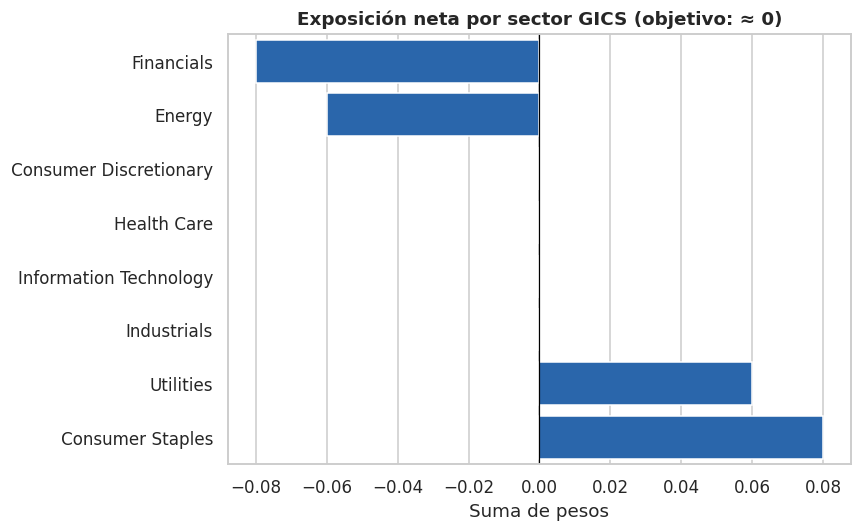

Máxima desviación sectorial absoluta: 0.0800


,net_weight
gics_sector,
Financials,-0.08
Energy,-0.06
Consumer Discretionary,0.00
Health Care,0.00
Information Technology,0.00
Industrials,0.00
Utilities,0.06
Consumer Staples,0.08


In [3]:
sector_exposure = weights.groupby("gics_sector")["weight"].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=sector_exposure.values, y=sector_exposure.index, color="#1565C0", ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Exposición neta por sector GICS (objetivo: ≈ 0)")
ax.set_xlabel("Suma de pesos")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(f"Máxima desviación sectorial absoluta: {sector_exposure.abs().max():.4f}")
sector_exposure.to_frame("net_weight")

## Conclusión y próximos pasos

La cartera mostrada arriba es el resultado de un pipeline de investigación completo:
construcción del factor QMJ sobre datos contables de SEC EDGAR, neutralización sectorial y
de beta de mercado (residualización cross-sectional contra un beta histórico estimado con
Rolling OLS), y optimización mean-variance dollar-neutral con una matriz de covarianza
shrinkage (Ledoit-Wolf) vía `cvxpy`. Por construcción, la cartera es *ortogonal al beta de
mercado* — el score que alimenta al optimizador ya no contiene la componente de retorno
explicada linealmente por la exposición a mercado — y *sectorialmente neutral*, como se
verificó arriba empíricamente.

**Siguiente paso natural:** estos pesos objetivo son el input directo de `var-engine`
(el motor de risk management en C99 del mismo repositorio) para el cálculo de VaR
paramétrico/histórico/Monte Carlo y el backtesting formal (Kupiec, Christoffersen) de la
cartera resultante — cerrando el ciclo entre generación de alpha (`factor-lab`) y gestión
de riesgo (`var-engine`) que motivó este proyecto desde el inicio.

**Limitaciones a declarar explícitamente ante el comité:** los fundamentals de este
rebalanceo específico pueden provenir del panel *simulado* de `run_pipeline.py`
(`source_tag="SIMULATED"`) si `use_real_sec=False` — verificar la procedencia de los datos
(`net_income_source_tag`, etc.) antes de presentar estos números como un resultado de
investigación real, no como una prueba de concepto de la arquitectura.